In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.shape

(768, 9)

In [5]:
# checking null value 
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
## lets check the correlation with output feature
df_corr=df.copy()
df_corr.corr()['Outcome'].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

In [23]:
len(df.columns[:-1]),len(df_corr.corr()['Outcome'].sort_values(ascending=False)[1:])

(8, 8)

C:\Users\Rahul\AppData\Local\Temp\ipykernel_2340\2554542751.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


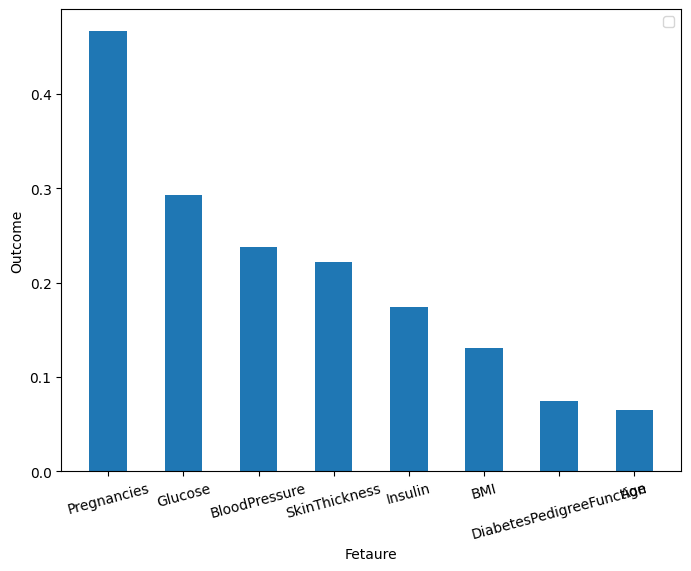

In [40]:
plt.figure(figsize=(8,6))
plt.style.available='_mpl-gallery'
X=df_corr.corr()['Outcome'].sort_values(ascending=False)[1:]
labels=list(df.columns[:-1])
plt.bar(x=df.columns[:-1],height=X,width=0.5)
plt.xlabel("Fetaure")
plt.xticks(rotation=15)
plt.ylabel("Outcome")
plt.legend(loc="upper right")
plt.show()

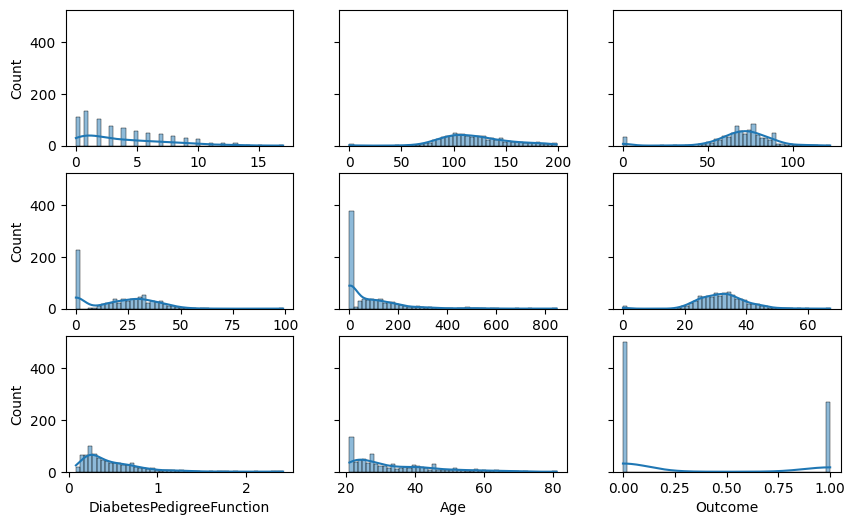

In [72]:
import seaborn as sns
fig,axes = plt.subplots(nrows=3,ncols=3,figsize=(10,6),sharey='all')
i,j=0,0 # i=rows and j=columns
for idx,col in enumerate(df.columns):
    if(idx==3 or idx==6 or idx==9):
        i+=1
        j=0
    sns.histplot(data=df[col],bins=50,kde=True,ax=axes[i][j],label=col)
    plt.xlabel(col)
    j+=1

In [77]:
df['SkinThickness'].value_counts()[0] , df['Insulin'].value_counts()[0]
## lets see what happen after scaling it 

(np.int64(227), np.int64(374))

In [78]:
X=df.drop(columns=['Outcome'])
y=df['Outcome']

In [79]:
### lets check the imbalance so that we can decide our split 
y.value_counts()/y.shape

Outcome
0    0.651042
1    0.348958
Name: count, dtype: float64

In [81]:
### so in  this case their is not much need to staratify the split and their are not group present in the data so not group split lets go with basic split 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(f"Shape of X_train : {X_train.shape}")
print(f"Shape of X_test : {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test : {y_test.shape}")

Shape of X_train : (614, 8)
Shape of X_test : (154, 8)
Shape of y_train: (614,)
Shape of y_test : (154,)


In [83]:
## lets create and pipeline to automate the scaling of data 
## For this purpose we are going with standard scalar to get (normal distribution of data )
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
transformationPipeline=Pipeline([
    ('scaling',StandardScaler())
])
X_train_transformed = transformationPipeline.fit_transform(X_train)
X_test_transfromed = transformationPipeline.transform(X_test)

In [111]:
### Method to check the model metrics
from sklearn.metrics import recall_score,f1_score,roc_auc_score,roc_curve,auc
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
def model_metrics(model,model_name,y_train,y_pred,y_pred_proba):
    recall  = recall_score(y_train,y_pred)
    f1_scores  = f1_score(y_train,y_pred)
    print(f"Model : {model_name}")
    print(f"Recall Score  : {recall}")
    print(f"F1 Score : {f1_scores}")
    print(f"Confusion Matrix ")
    cm = confusion_matrix(y_train,y_pred)
    ConfusionMatrixDisplay(cm,display_labels=['Not Dibeates','Dibeates']).plot()
    print(f"Roc Auc plot")
    fpr,tpr,tr = roc_curve(y_train,y_pred_proba)
    roc_auc = auc(fpr,tpr)
    plt.figure(figsize=(4,4))
    plt.plot(fpr,tpr,label=f'{model} (AUC = {roc_auc:.2f})')
    plt.plot([0,1],[0,1],'g--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Roc Auc Plot")
    plt.tight_layout()
    plt.legend(loc='lower right')
    plt.show()

Model : Logistic Regression
Recall Score  : 0.5586854460093896
F1 Score : 0.6279683377308707
Confusion Matrix 
Roc Auc plot


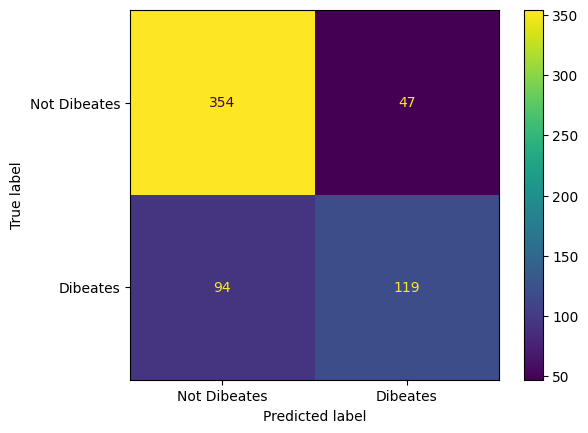

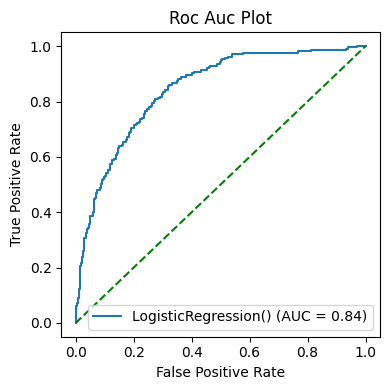

In [113]:
### Now lets create and model so for this case we required more recall as primary metric and model we are refering is 
### logistic regression , decision tree classifier , random forest classifier 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
## metric 
from sklearn.metrics import recall_score,f1_score,roc_auc_score,roc_curve,auc
## Logistic regression 
logistic = LogisticRegression()
logistic.fit(X_train_transformed,y_train)
y_pred = logistic.predict(X_train_transformed)
y_pred_proba = logistic.predict_proba(X_train_transformed)[:,1]
model_metrics(logistic,'Logistic Regression',y_train,y_pred,y_pred_proba)

Model : Decision Tree Classifier
Recall Score  : 1.0
F1 Score : 1.0
Confusion Matrix 
Roc Auc plot


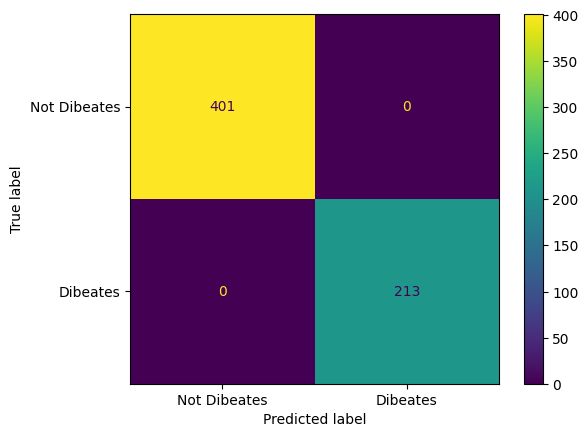

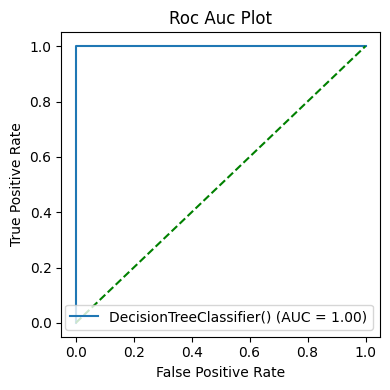

In [114]:
## model : Decision Tree Classifier
decisionTree = DecisionTreeClassifier()
decisionTree.fit(X_train_transformed,y_train)
y_pred = decisionTree.predict(X_train_transformed)
y_pred_proba = decisionTree.predict_proba(X_train_transformed)[:,1]
model_metrics(decisionTree,'Decision Tree Classifier',y_train,y_pred,y_pred_proba)

Model : Random Forest Classifier
Recall Score  : 1.0
F1 Score : 1.0
Confusion Matrix 
Roc Auc plot


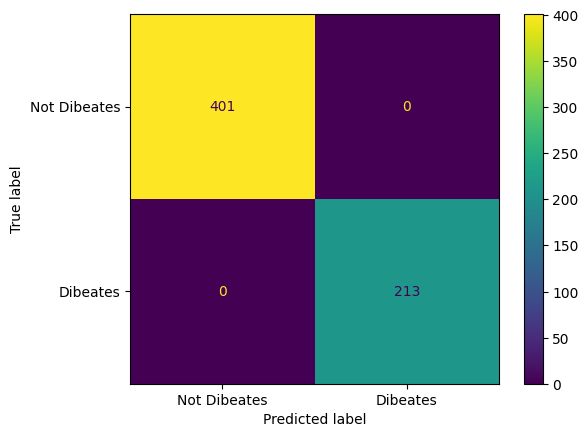

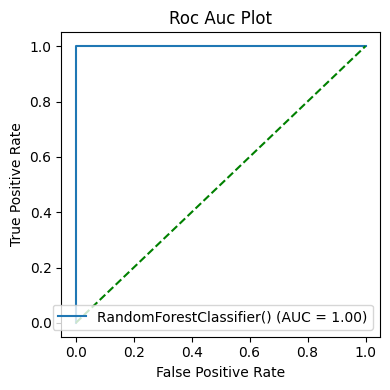

In [115]:
## model : Random Forest Classifier
randomForest = RandomForestClassifier()
randomForest.fit(X_train_transformed,y_train)
y_pred = randomForest.predict(X_train_transformed)
y_pred_proba = randomForest.predict_proba(X_train_transformed)[:,1]
model_metrics(randomForest,'Random Forest Classifier',y_train,y_pred,y_pred_proba)

In [119]:
### Checking the model overfiiting by corss validition 
from sklearn.model_selection import cross_val_score
score1 = cross_val_score(decisionTree,X_train_transformed,y_train,verbose=1,n_jobs=-1,cv=3)
score2 = cross_val_score(decisionTree,X_train_transformed,y_train,scoring='recall',verbose=1,n_jobs=-1,cv=3)
print("Cross validation for model : Decision Tree Classifier for cv=3")
print(f"Without scoring  : {score1}")
print(f"With Scoring : {score2}")

Cross validation for model : Decision Tree Classifier for cv=3
Without scoring  : [0.74634146 0.74634146 0.71568627]
With Scoring : [0.53521127 0.61971831 0.52112676]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:    0.0s finished


In [120]:
### Checking the model overfiiting by corss validition 
from sklearn.model_selection import cross_val_score
score1 = cross_val_score(randomForest,X_train_transformed,y_train,verbose=1,n_jobs=-1,cv=3)
score2 = cross_val_score(randomForest,X_train_transformed,y_train,scoring='recall',verbose=1,n_jobs=-1,cv=3)
print("Cross validation for model : Random Forest Classifier for cv=3")
print(f"Without scoring  : {score1}")
print(f"With Scoring : {score2}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Cross validation for model : Random Forest Classifier for cv=3
Without scoring  : [0.7804878  0.77073171 0.75980392]
With Scoring : [0.5915493  0.5915493  0.53521127]


[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:    0.5s finished


In [121]:
### Checking the model overfiiting by corss validition 
from sklearn.model_selection import cross_val_score
score1 = cross_val_score(logistic,X_train_transformed,y_train,verbose=1,n_jobs=-1,cv=3)
score2 = cross_val_score(logistic,X_train_transformed,y_train,scoring='recall',verbose=1,n_jobs=-1,cv=3)
print("Cross validation for model : Logistic Regression for cv=3")
print(f"Without scoring  : {score1}")
print(f"With Scoring : {score2}")

Cross validation for model : Logistic Regression for cv=3
Without scoring  : [0.8        0.76585366 0.73529412]
With Scoring : [0.64788732 0.56338028 0.50704225]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:    0.0s finished


In [125]:
## Okay so from all three model the logistic regression a=had performed well in corss validation so lets do hyper parameter tuning and then check the reacll 
from sklearn.model_selection import GridSearchCV
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', None], 
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}
grid_search = GridSearchCV(logistic, param_grid_refined, cv=5, verbose=1, n_jobs=-1,scoring='recall')
grid_search.fit(X_train_transformed, y_train)
print(f"best Parameter  : {grid_search.best_params_}")

Fitting 5 folds for each of 145 candidates, totalling 725 fits
best Parameter  : {'C': np.float64(0.012742749857031334), 'penalty': 'l1', 'solver': 'liblinear'}


C:\Users\Rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 725.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
17 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "C:\Users\Rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.p

Model : Logistic Regression
Recall Score  : 0.7464788732394366
F1 Score : 0.6334661354581673
Confusion Matrix 
Roc Auc plot


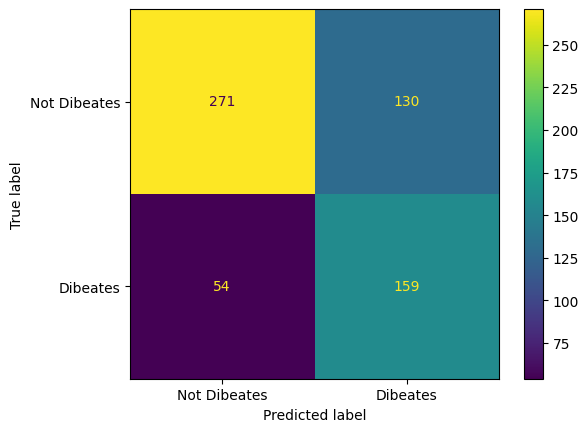

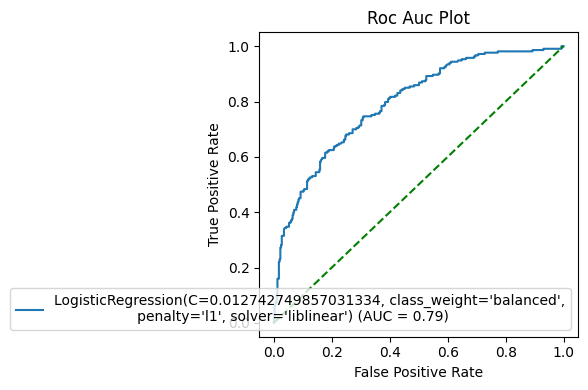

In [127]:
### lets create and model logistic regression again 
logistic = LogisticRegression(penalty='l1',C=0.012742749857031334 , solver='liblinear',class_weight='balanced')
logistic.fit(X_train_transformed,y_train)
y_pred = logistic.predict(X_train_transformed)
y_pred_proba = logistic.predict_proba(X_train_transformed)[:,1]
model_metrics(logistic,'Logistic Regression',y_train,y_pred,y_pred_proba)

In [130]:
### okay setting class_weight = 'balanced' had correctly balanced the data by increasing the recall 
### So lest dump the model 
import joblib
joblib.dump(transformationPipeline,'transformationPipeline.joblib')
joblib.dump(logistic,'logisticRegression.joblib')

['logisticRegression.joblib']